<div align="right">
АС-23-05, Тищенко Кирилл, Вариант №97
</div>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f
from scipy.stats import t
from scipy.stats import spearmanr, rankdata
from scipy import stats
from IPython.display import display

# Лабортаторная работа № 3 "Корреляционный анализ"

In [2]:
df = pd.read_excel('data3.xlsx', sheet_name = '2-1', header = None)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       50 non-null     float64
 1   1       50 non-null     float64
 2   2       50 non-null     float64
 3   3       50 non-null     float64
 4   4       50 non-null     float64
dtypes: float64(5)
memory usage: 2.1 KB


## Корреляционная матрица

$$r_{XY} = \frac{\sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})}
             {\sqrt{\sum_{i=1}^{n} (X_i - \bar{X})^2 \cdot \sum_{i=1}^{n} (Y_i - \bar{Y})^2}}$$

In [3]:
def corr_matrix_pirson(df):
    data = df.values
    n = data.shape[1]
    cols = df.columns
    res = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            x = data[:, i]
            y = data[:, j]
            xm = x.mean()
            ym = y.mean()
            num = ((x - xm) * (y - ym)).sum()
            den = np.sqrt(((x - xm)**2).sum() * ((y - ym)**2).sum())
            res[i, j] = num / den
    return pd.DataFrame(res, index=cols, columns=cols)

## Матрица p-values для парных коэффициентов Пирсона

$$t = r \cdot \sqrt{\frac{n-2}{1-r^2}}$$
$$p = 2 \cdot \Big( 1 - F_t(|t|, \text{df}=n-2) \Big)$$

In [3]:
def pval_matrix(corr, df):
    n = len(df)
    cols = df.columns
    res = np.zeros((len(cols), len(cols)))
    for i in range(len(cols)):
        for j in range(len(cols)):
            if i == j:
                res[i, j] = 0
                continue
            r = corr.iloc[i, j]
            if abs(r) == 1:
                res[i, j] = 0
                continue
            t_stat = r * np.sqrt((n - 2) / (1 - r**2))
            p = 2 * (1 - t.cdf(abs(t_stat), df=n-2))
            res[i, j] = p

    return pd.DataFrame(res, index=cols, columns=cols)

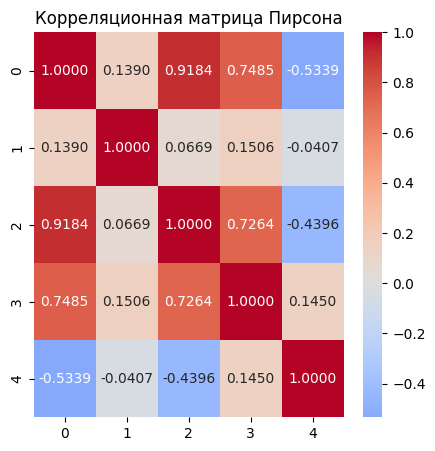

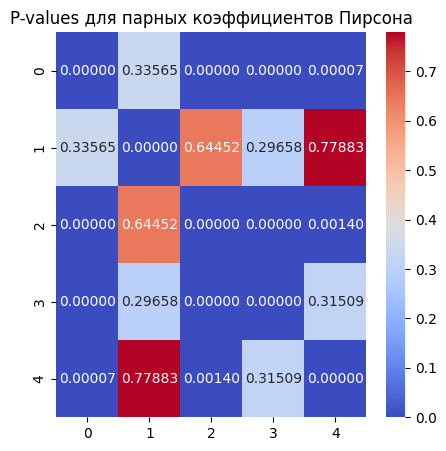

In [5]:
corr = corr_matrix_pirson(df)
pvals = pval_matrix(corr, df)

plt.figure(figsize=(5, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".4f",
    cmap="coolwarm",
    center=0
)
plt.title("Корреляционная матрица Пирсона")
plt.show()

plt.figure(figsize=(5, 5))
sns.heatmap(
    pvals,
    annot=True,
    fmt=".5f",
    cmap="coolwarm"
)
plt.title("P-values для парных коэффициентов Пирсона")
plt.show()

По результатам анализа можно разделить связи на следующие группы:
1. **Сильные и статистически значимые (|r| ≥ 0.7, p < 0.05)**  
0 - 2 (r = 0.918, p = 0)  
0 - 3 (r = 0.749, p = 4.1e-10)  
2 - 3 (r = 0.726, p = 2.35e-09)  
2. **Умеренные и статистически значимые (0.3 ≤ |r| < 0.7, p < 0.05)**  
0 - 4 (r = -0.534, p = 6.5e-05)  
2 - 4 (r = -0.440, p = 0.0014)  
3. **Сильные или умеренные, но статистически не значимые (p ≥ 0.05)**  
Все связи |r| ≥ 0.3 оказались значимыми  
4. **Слабые и статистически не значимые (|r| < 0.3 или p ≥ 0.05)**  
0 - 1 (r = 0.139, p = 0.336)  
1 - 2 (r = 0.067, p = 0.645)    
1 - 3 (r = 0.151, p = 0.297)  
1 - 4 (r = -0.041, p = 0.779)  
3 - 4 (r = 0.145, p = 0.315)  

## Частные коэффициенты корреляции

$$r_{ij \cdot \text{rest}} = - \frac{ \left| R_{[ij]} \right| }{ \sqrt{ \left| R_{[ii]} \right| \cdot \left| R_{[jj]} \right| } }$$
$$t = r_{ij \cdot \text{rest}} \sqrt{\frac{n - k - 2}{1 - r_{ij \cdot \text{rest}}^2}}$$
$$p = 2 \cdot \left( 1 - F_t\left(|t|, \, df = n - k - 2 \right) \right)$$

In [6]:
def partial_correlation_matrix(data):
    cols = data.columns
    n = len(cols)
    corr_matrix = data.corr().values
    part_corr = np.zeros((n, n))
    part_p = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                part_corr[i, j] = 1.0
                part_p[i, j] = 0.0
            else:
                R = corr_matrix.copy()
                R_ii = np.delete(np.delete(R, i, axis=0), i, axis=1)
                R_jj = np.delete(np.delete(R, j, axis=0), j, axis=1)
                R_ij = np.delete(np.delete(R, i, axis=0), j, axis=1)
                sign = (-1) ** (i + j)
                det_R_ii = np.linalg.det(R_ii)
                det_R_jj = np.linalg.det(R_jj)
                det_R_ij = np.linalg.det(R_ij)
                part_corr[i, j] = -sign * det_R_ij / np.sqrt(det_R_ii * det_R_jj)
                dfree = len(data) - (n - 2) - 2
                if dfree > 0 and abs(part_corr[i, j]) < 1:
                    t_stat = part_corr[i, j] * np.sqrt(dfree / (1 - part_corr[i, j]**2))
                    part_p[i, j] = 2 * (1 - t.cdf(abs(t_stat), df=dfree))
                else:
                    part_p[i, j] = 1.0
                    
    return pd.DataFrame(part_corr, index=cols, columns=cols), pd.DataFrame(part_p, index=cols, columns=cols)

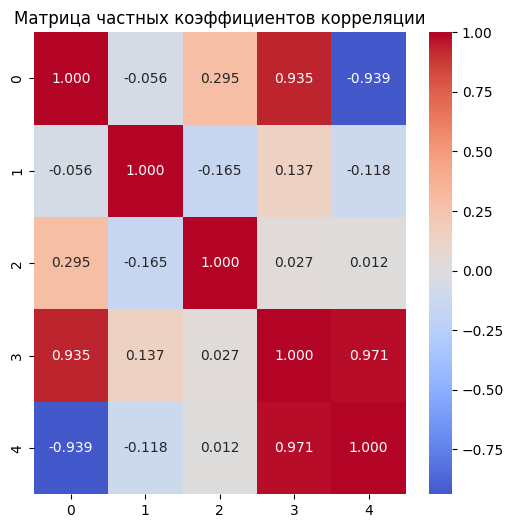

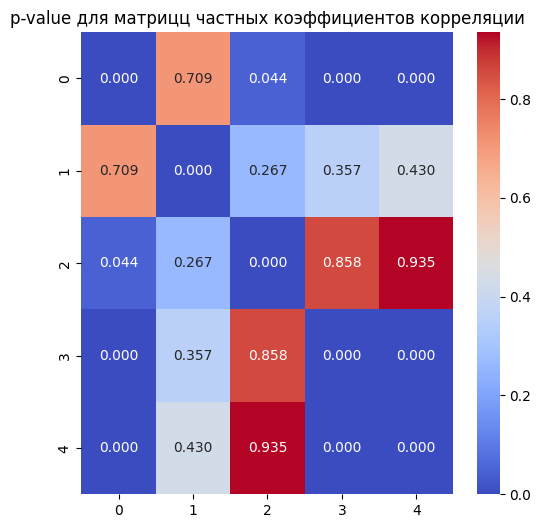

In [7]:
pc_matrix, pc_pvals = partial_correlation_matrix(df)

plt.figure(figsize=(6, 6))
sns.heatmap(pc_matrix, annot=True, fmt=".3f", cmap="coolwarm", center=0)
plt.title("Матрица частных коэффициентов корреляции")
plt.show()

plt.figure(figsize=(6, 6))
sns.heatmap(pc_pvals, annot=True, fmt=".3f", cmap="coolwarm")
plt.title("p-value для матрицц частных коэффициентов корреляции")
plt.show()

На основе этого анализа можно сделать следующие выводы:
1. **Чистые, независимые связи**:  
0 - 3, 3 - 4, 0 - 4 — сильные и значимые  
2. **Связи, зависящие от других переменных**:  
0 - 2 — умеренная после контроля, была сильной до контроля  
2 - 3 — почти исчезла  
3. **Слабые или незначимые**:  
Все остальные пары  

## Множественные коэффициенты корреляции

$$R_i = \sqrt{1 - \frac{|R|}{|R_{[ii]}|}}$$
$$F = \frac{R^2 / k}{(1 - R^2)(n - k - 1)}$$

In [8]:
def multiple_correlation_det(data):
    cols = data.columns
    R_vals = pd.Series(index=cols, dtype=float)
    pval = pd.Series(index=cols, dtype=float)
    R = data.corr().values
    det_R = np.linalg.det(R)
    n = len(data)
    m = len(cols)
    for i, dep in enumerate(cols):
        R_ii = np.delete(np.delete(R, i, axis=0), i, axis=1)
        det_R_ii = np.linalg.det(R_ii)
        R_sq = 1 - det_R / det_R_ii
        R_vals[dep] = np.sqrt(R_sq)
        k = m - 1
        F = (R_sq / k) / ((1 - R_sq) / (n - k - 1))
        pval[dep] = 1 - f.cdf(F, k, n - k - 1)
    
    return R_vals, pval

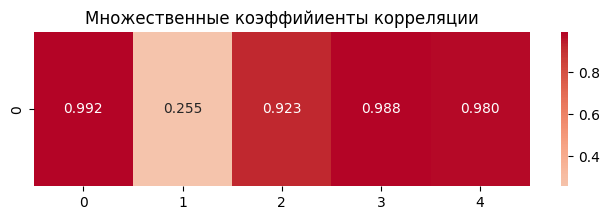

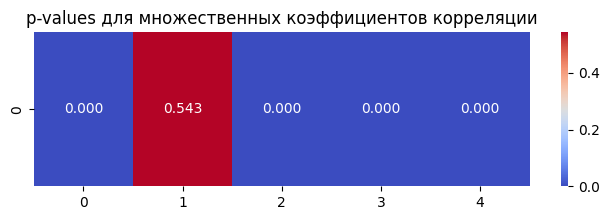

In [9]:
R_vals, pvals = multiple_correlation_det(df)

plt.figure(figsize=(8, 2))
sns.heatmap(R_vals.to_frame().T, annot=True, fmt=".3f", cmap="coolwarm", center=0)
plt.title("Множественные коэффийиенты корреляции")
plt.show()

plt.figure(figsize=(8, 2))
sns.heatmap(pvals.to_frame().T, annot=True, fmt=".3f", cmap="coolwarm")
plt.title("р-values для множественных коэффициентов корреляции")
plt.show()

Выводы:  
Переменная 1 практически не зависит от остальных, связь слабая и статистически незначимая   
Остальные переменные (0, 2, 3, 4) имеют сильные и статистически значимые зависимости, то есть можно почти полностью предсказать их через остальные  
Это согласуется с предыдущими выводами по частной корреляции: большая часть взаимных зависимостей сосредоточена между 0, 2, 3, 4, а 1 — относительно независимая

## Коэффициенты ранговой корреляции Спирмана

$$r_s = 1 - \frac{6 \sum d^2}{n(n^2 - 1)}$$
$$t = \frac{r_s \sqrt{n - 2}}{\sqrt{1 - r_s^2}}$$

In [10]:
def spearman_matrix(df):
    cols = df.columns
    n = len(cols)
    corr = np.zeros((n, n))
    pvals = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            if i == j:
                corr[i, j] = 1.0
                pvals[i, j] = 0.0
            else:
                x = rankdata(df.iloc[:, i])
                y = rankdata(df.iloc[:, j])
                r, p = spearmanr(x, y)
                corr[i, j] = r
                pvals[i, j] = p
    
    return pd.DataFrame(corr, index=cols, columns=cols), pd.DataFrame(pvals, index=cols, columns=cols)

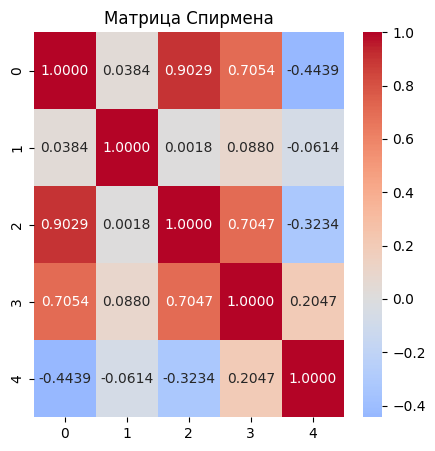

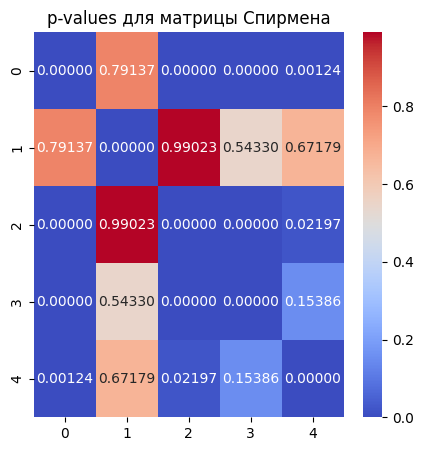

In [13]:
corr_s, pvals_s = spearman_matrix(df)

plt.figure(figsize=(5, 5))
sns.heatmap(corr_s, annot=True, fmt=".4f", cmap="coolwarm", center=0)
plt.title("Матрица Спирмена")
plt.show()

plt.figure(figsize=(5, 5))
sns.heatmap(pvals_s, annot=True, fmt=".5f", cmap="coolwarm")
plt.title("p-values для матрицы Спирмена")
plt.show()

Переменная 1 практически не связана с остальными (слабые корреляции и высокие p-value)  
Переменные 0, 2, 3, 4 образуют группу взаимосвязанных признаков:  
0, 2, 3 — сильная и значимая связь  
0 - 4 и 2 - 4 — умеренная, но значимая связь   

В сравнении с матрицей Пирсона:  
Основные сильные связи сохранились (0 - 2, 0 - 3, 2 - 3)  
Знак и сила некоторых умеренных связей изменились (например, 0↔4 стала отрицательной)  
Спирмен выявляет монотонные зависимости, не обязательно линейные  

Вывод:

Переменная 1 — изолированная  
Остальные переменные (0, 2, 3, 4) формируют взаимосвязанную группу  

## Корреляционные отношения

$$
\eta^2 = \frac{\sum_{j} n_j (\bar{y}_j - \bar{y})^2}{\sum_{i} (y_i - \bar{y})^2}
$$

In [15]:
def correlation_ratio_matrix(df, bins=10):
    cols = df.columns
    n = len(cols)
    eta = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                eta[i, j] = 1.0
            else:
                x = df.iloc[:, i]
                y = df.iloc[:, j]
                categories = pd.cut(x, bins=bins)
                y_mean = y.mean()
                ss_between = 0
                ss_total = ((y - y_mean) ** 2).sum()
                for cat in categories.unique():
                    y_cat = y[categories == cat]
                    if len(y_cat) > 0:
                        ss_between += len(y_cat) * (y_cat.mean() - y_mean) ** 2
                eta[i, j] = ss_between / ss_total if ss_total != 0 else 0
    
    return pd.DataFrame(eta, index=cols, columns=cols)

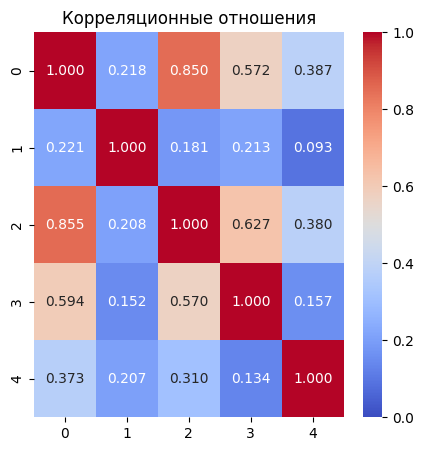

In [18]:
eta_matrix = correlation_ratio_matrix(df)

plt.figure(figsize=(5, 5))
sns.heatmap(
    eta_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=0,
    vmax=1
)

plt.title("Корреляционные отношения")
plt.show()

In [19]:
def eta_f_test_matrix(df, bins=10):
    cols = df.columns
    n_cols = len(cols)
    eta = np.zeros((n_cols, n_cols))
    F_mat = np.zeros((n_cols, n_cols))
    pvals = np.zeros((n_cols, n_cols))
    n = len(df)
    for i in range(n_cols):
        for j in range(n_cols):
            if i == j:
                eta[i, j] = 1.0
                F_mat[i, j] = 0.0
                pvals[i, j] = 0.0
            else:
                x = df.iloc[:, i]
                y = df.iloc[:, j]
                categories = pd.cut(x, bins=bins)
                y_mean = y.mean()
                ss_between = 0
                ss_total = ((y - y_mean) ** 2).sum()
                groups = categories.unique()
                k = len(groups)
                for cat in groups:
                    y_cat = y[categories == cat]
                    if len(y_cat) > 0:
                        ss_between += len(y_cat) * (y_cat.mean() - y_mean) ** 2
                eta_sq = ss_between / ss_total if ss_total != 0 else 0
                eta[i, j] = eta_sq
                if k > 1 and n > k:
                    F_stat = (eta_sq / (k - 1)) / ((1 - eta_sq) / (n - k))
                    F_mat[i, j] = F_stat
                    pvals[i, j] = 1 - f.cdf(F_stat, k - 1, n - k)
                else:
                    F_mat[i, j] = 0.0
                    pvals[i, j] = 1.0
    
    return (
        pd.DataFrame(eta, index=cols, columns=cols),
        pd.DataFrame(F_mat, index=cols, columns=cols),
        pd.DataFrame(pvals, index=cols, columns=cols)
    )

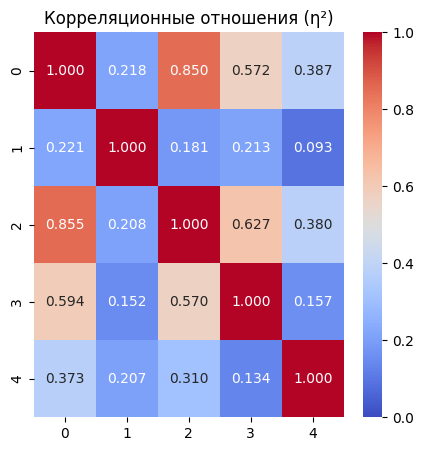

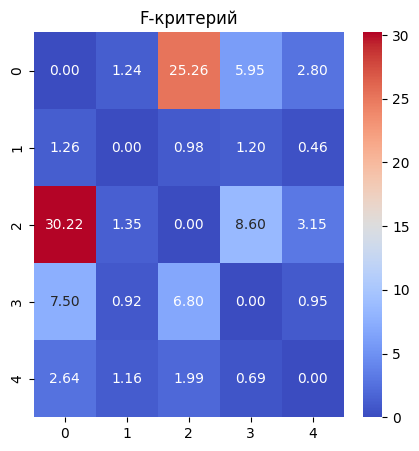

In [24]:
eta, F_mat, pvals = eta_f_test_matrix(df)

plt.figure(figsize=(5, 5))
sns.heatmap(eta, annot=True, fmt=".3f", cmap="coolwarm", vmin=0, vmax=1)
plt.title("Корреляционные отношения (η²)")
plt.show()

plt.figure(figsize=(5, 5))
sns.heatmap(F_mat, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("F-критерий")
plt.show()

Сильные зависимости (η² > 0.5):
0 ↔ 2 ≈ 0.85 → очень сильная зависимость  
2 ↔ 3 ≈ 0.63 → сильная  
0 ↔ 3 ≈ 0.57 → сильная  

Умеренные зависимости (0.3 – 0.5):
0 ↔ 4 ≈ 0.39  
2 ↔ 4 ≈ 0.38  

Слабые:
Все связи с переменной 1 (0.09–0.22)  
3 ↔ 4 (0.15)


️F-критерий
Значимые (примерно F > ~2–3)

0 ↔ 2 → F ≈ 25–30  очень значимо  
2 ↔ 3 → F ≈ 6–8  значимо  
0 ↔ 3 → F ≈ 5–7  значимо  
0 ↔ 4 → F ≈ 2.6–2.8  на границе значимости  
2 ↔ 4 → F ≈ 3.1  значимо  
Не значимые:  
Все связи с 1 (F ≈ 0.4–1.3)  
3 ↔ 4 ≈ 0.68–0.95  
Итог по группам  
Сильные и значимые  
0 ↔ 2  
0 ↔ 3  
2 ↔ 3  

Умеренные и значимые  
2 ↔ 4  
0 ↔ 4  
Слабые и незначимые  
все связи с 1  
3 ↔ 4  
Новое от η²:  
η² показывает, что:
0 ↔ 4 и 2 ↔ 4 имеют зависимость, скорее всего нелинейную

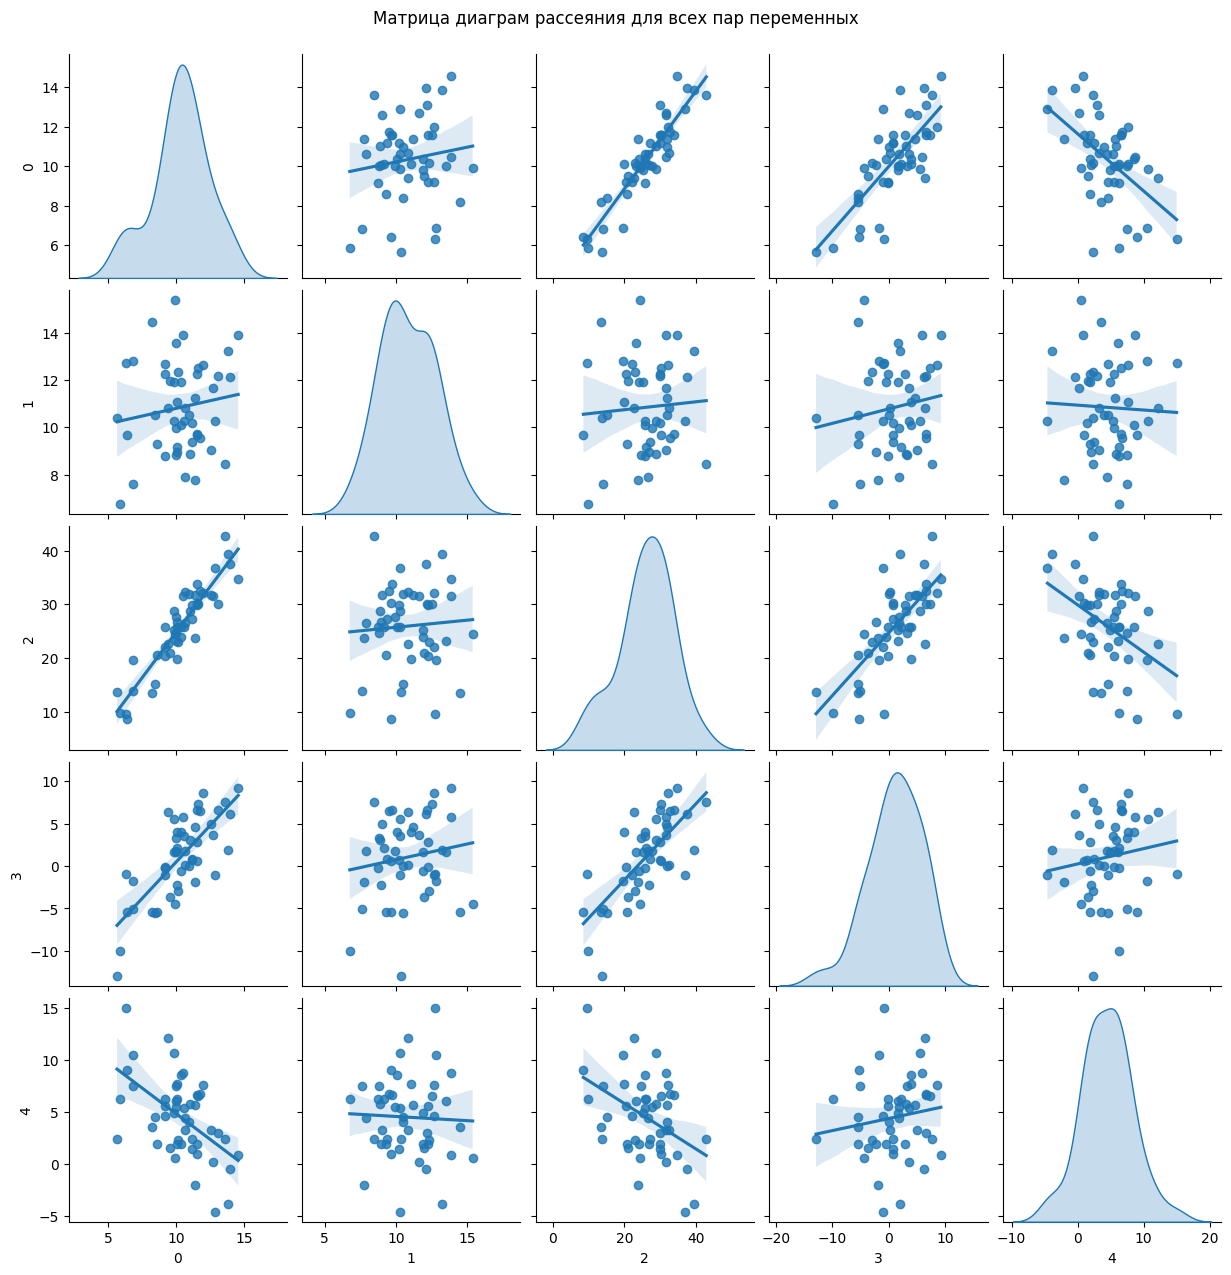

In [25]:
sns.pairplot(
    df,
    diag_kind="kde",
    kind="reg"
)

plt.suptitle("Матрица диаграм рассеяния для всех пар переменных", y=1.02)
plt.show()

## Вывод
Ядро сильно связанных переменных
0, 2, 3
- Пирсон: сильные корреляции
- Спирмен: сильные монотонные связи
- Частные корреляции: связи сохраняются (особенно 0–3)
- η²: сильные зависимости
- Множественный R: близок к 1


Связь:
- сильная
- статистически значимая
- частично независимая (не исчезает при контроле других)

Переменная 4 — связанная, но вторичная
- Пирсон: умеренная связь с 0 и 2
- Спирмен: подтверждает (монотонная связь)
- Частная корреляция: связь усиливается (например, с 3)
- η²: показывает зависимость (возможно нелинейную)
- Множественный R: высокий (~0.98)


Переменная 4:
- связана с основной группой (0, 2, 3)
- но слабее и менее устойчиво

Переменная 1 — изолированная
- Пирсон: слабые корреляции
- Спирмен: слабые
- Частные корреляции: почти ноль
- η²: слабые значения
- Множественный R: низкий (~0.25), p-value незначим

Переменная 1:
- практически не связана с другими
- статистически незначима